# 问卷数据

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict
from matplotlib.font_manager import FontProperties
from wordcloud import WordCloud
from collections import Counter
import re
import jieba


def parse_content(content_str):
    try:
        return json.loads(content_str)
    except json.JSONDecodeError:
        try:
            # Attempt to fix common JSON issues
            fixed_content = content_str.replace("'", '"').replace("True", "true").replace("False", "false")
            return json.loads(fixed_content)
        except:
            return {'list': []}
    except TypeError:
        return {'list': []}

# Function to clean Chinese text
def clean_chinese_text(text):
    # Remove non-Chinese characters except basic punctuation
    cleaned = re.sub(r'[^\u4e00-\u9fa5，。！？、：；“”‘’（）【】《》\s]', '', text)
    # Remove extra spaces
    return re.sub(r'\s+', ' ', cleaned).strip()

survey_df = pd.read_csv(
    '/home/mzyy1001/business/data/2025-05-31-10-01-50_EXPORT_CSV_19470858_516_ds_survey_feedback_0.csv',
    encoding='utf-8',
    on_bad_lines='skip'
)
survey_id = 1000004
survey_df = survey_df[survey_df['survey_id']==survey_id]

# Data structure: 
# {survey_id: {sub_survey_id: {uniqueId: {type: str, question: str, answers: dict/text_responses}}}}
results = defaultdict(lambda:defaultdict(lambda: defaultdict(lambda: {
    'type': '',
    'question': '',
    'answers': defaultdict(int),
    'text_responses': []
})))

/home/mzyy1001/business/venv/lib/python3.12/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/tmp/ipykernel_680436/3789718995.py:33: DtypeWarning: Columns (0: sales_id) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_df = pd.read_csv(


In [2]:
survey_groups = survey_df.groupby('sub_survey_id')

for sub_survey_id, group in survey_groups:
    print(f"\nProcessing Sub-Survey ID: {sub_survey_id}")
    print(f"Number of Responses: {len(group)}")
    
    # Process each response in the group
    for idx, row in group.iterrows():
        content = parse_content(row['content'])
        questions = content.get('list', [])
        
        for question in questions:
            if 'uniqueId' not in question or 'question' not in question or 'type' not in question:
                print(f"Skipping malformed question in response {idx} of sub-survey {sub_survey_id}")
                continue
            
            unique_id = question['uniqueId']
            q_type = question['type']
            q_text = question['question']

            if q_type=='type':
                pass
            
            # print(f"Question ID: {unique_id}, Type: {q_type}, Text: {q_text}")
            

            # Initialize question entry if first encounter
            if not results[survey_id][sub_survey_id][unique_id]['question']:
                results[survey_id][sub_survey_id][unique_id] = {
                    'type': q_type,
                    'question': q_text,
                    'answers': defaultdict(int),
                    'text_responses': []
                }

            # Process based on question type
            if q_type in ['single', 'mul']:
                # Process choice-based questions
                if 'answers' in question:
                    for answer in question['answers']:
                        if answer.get('selected', False):
                            answer_text = answer.get('text', '')
                            results[survey_id][sub_survey_id][unique_id]['answers'][answer_text] += 1
        
            elif q_type == 'text':
                # Process text responses
                text_response = ""
                if 'answers' in question:
                    for answer in question['answers']:
                        if 'text' in answer:
                            text_response += answer['text'] + " "
                    text_response = text_response.strip()
                
                if text_response:
                    # Clean and store text response
                    cleaned_text = clean_chinese_text(text_response)
                    if cleaned_text:
                        results[survey_id][sub_survey_id][unique_id]['text_responses'].append(cleaned_text)


Processing Sub-Survey ID: 1.0
Number of Responses: 27847

Processing Sub-Survey ID: 2.0
Number of Responses: 3481

Processing Sub-Survey ID: 3.0
Number of Responses: 3433

Processing Sub-Survey ID: 4.0
Number of Responses: 3458

Processing Sub-Survey ID: 5.0
Number of Responses: 3498

Processing Sub-Survey ID: 6.0
Number of Responses: 20990

Processing Sub-Survey ID: 7.0
Number of Responses: 1323

Processing Sub-Survey ID: 8.0
Number of Responses: 1415

Processing Sub-Survey ID: 9.0
Number of Responses: 1423

Processing Sub-Survey ID: 10.0
Number of Responses: 1383

Processing Sub-Survey ID: 11.0
Number of Responses: 1391


In [3]:
from tqdm import tqdm
import json
import re

from peft import PeftModel, PeftConfig

sub_surveys = [8.0, 9.0]

for survey_id, sub_survey in results.items():
    for sub_survey_id, questions in sub_survey.items():
        if sub_survey_id not in sub_surveys:
            continue

        for _, data in tqdm(questions.items(), desc=f"Processing Survey {survey_id}-{sub_survey_id}"):
            q_type = data['type']
            option_list = []
            if q_type in ['single', 'mul']:
                question_text = data['question']
                
                if '年龄' in question_text or '常驻' in question_text:
                    continue  # 跳过人口统计问题
                
                # 获取真实答案分布
                true_counts = data['answers']

                print(f"Question ID: {unique_id}, Type: {q_type}, Text: {question_text}")
                print(f"True Answer Distribution: {true_counts}")

/home/mzyy1001/business/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing Survey 1000004-8.0: 100%|██████████| 7/7 [00:00<00:00, 50533.78it/s]


Question ID: qsingle_6, Type: single, Text: 您是否知道肠胃感冒?
True Answer Distribution: defaultdict(<class 'int'>, {'是': 890, '否': 525})
Question ID: qsingle_6, Type: single, Text: 请问您认为哪个季节容易发生肠胃感冒?
True Answer Distribution: defaultdict(<class 'int'>, {'全年': 232, '夏': 263, '冬': 123, '秋': 119, '春': 153})
Question ID: qsingle_6, Type: single, Text: 请问您发生肠胃感冒的场景往往是? 
True Answer Distribution: defaultdict(<class 'int'>, {'冷热刺激(高温乘凉不当、猛吹空调等)': 303, '天气变化大': 157, '饮食不良(喜吃辛辣、冰饮等)': 275, '病毒感染': 138, '其他': 17})
Question ID: qsingle_6, Type: single, Text: 您一般用什么方法来缓解肠胃感冒症状?
True Answer Distribution: defaultdict(<class 'int'>, {'联合用药': 168, '藿香正气类产品': 470, '抗病毒用药': 154, '不在意': 90, '其他': 8})
Question ID: qsingle_6, Type: single, Text: 您是否会购买太极藿香正气口服液解决这些症状
True Answer Distribution: defaultdict(<class 'int'>, {'是': 416, '否': 53})


Processing Survey 1000004-9.0: 100%|██████████| 7/7 [00:00<00:00, 31468.52it/s]

Question ID: qsingle_6, Type: single, Text: 您过去一年内是否有湿气重的症状(身体沉重、精神不振、皮肤问题等)?
True Answer Distribution: defaultdict(<class 'int'>, {'是': 884, '否': 539})
Question ID: qsingle_6, Type: single, Text: 请问您觉得产生湿气的原因是? 
True Answer Distribution: defaultdict(<class 'int'>, {'体质问题': 183, '久坐不运动': 248, '爱吃冷饮、火锅': 269, '环境潮湿': 170, '其他': 14})
Question ID: qsingle_6, Type: single, Text: 您觉得湿气重更容易发生在哪个季节?
True Answer Distribution: defaultdict(<class 'int'>, {'夏': 254, '秋': 100, '春': 152, '全年': 258, '冬': 120})
Question ID: qsingle_6, Type: single, Text: 您一般用什么方法来缓解湿气重的症状?
True Answer Distribution: defaultdict(<class 'int'>, {'不在意': 176, '饮食调理': 327, '刮痧、蒸桑拿、运动等': 303, '对症中药': 77})
Question ID: qsingle_6, Type: single, Text: 您是否会购买太极藿香正气口服液解决这些症状
True Answer Distribution: defaultdict(<class 'int'>, {'是': 61, '否': 16})


# 社交媒体数据

In [4]:
import pandas as pd

# Load the data
social_df = pd.read_csv('/home/mzyy1001/business/data/taiji_all.csv')

import re

import pandas as pd

# 确保 content_desc 列是字符串类型
social_df['content_desc'] = social_df['content_desc'].astype(str)
social_df['author_name'] = social_df['author_name'].astype(str)
social_df['content_desc'] = social_df['content_desc'].apply(lambda x: re.sub(r'#.*?#', '', str(x)))

filter_df_xhs = social_df[
    (social_df['data_channel'] == '小红书') &
    (social_df['content_desc'].str.len() < 200) &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))
].reset_index(drop=True)

filter_df_wb = social_df[
    (social_df['data_channel'] == '微博') &
    (social_df['content_desc'] != '转发微博') &
    (social_df['content_desc'].str.len() > 5) &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))  # 使用 ~ 表示不包含藿香茶
].reset_index(drop=True) #[['create_time', 'content_desc', 'pred_province']]

filter_df_jd = social_df[
    (social_df['data_channel'] == '京东') &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))  # 使用 ~ 表示不包含藿香茶
].reset_index(drop=True) #[['create_time', 'content_desc', 'pred_province']]

filter_df_tb = social_df[
    (social_df['data_channel'] == '淘宝') &
    (social_df['content_desc'].str.contains('藿香正气')) &
    ~(social_df['content_desc'].str.contains('藿香茶')) &
    ~(social_df['content_desc'].str.contains('廣藿香')) &
    ~(social_df['author_name'].str.contains('医')) &
    ~(social_df['author_name'].str.contains('药')) &
    ~(social_df['author_name'].str.contains('疗')) &
    ~(social_df['author_name'].str.contains('健康')) &
    ~(social_df['author_name'].str.contains('养生')) &
    ~(social_df['content_desc'].str.contains('育儿')) &
    ~(social_df['content_desc'].str.contains('@')) &
    ~(social_df['content_desc'].str.contains('藿香鱼'))  # 使用 ~ 表示不包含藿香茶
].reset_index(drop=True) #[['create_time', 'content_desc', 'pred_province']]

filter_df = pd.concat([filter_df_xhs, filter_df_wb], ignore_index=True)

# filter_df = filter_df.dropna(subset=['pred_province'])

# Drop duplicates: treat texts with 10 consecutive same characters as duplicates
def get_10char_substrings(text):
    """Extract all 10-character substrings from a text"""
    if len(text) < 10:
        return set()
    substrings = set()
    for i in range(len(text) - 9):
        substrings.add(text[i:i+10])
    return substrings

print(f"Before deduplication: {len(filter_df)} rows")

# First, do exact duplicate removal
filter_df = filter_df.drop_duplicates(subset=['content_desc'])
print(f"After exact duplicate removal: {len(filter_df)} rows")

# Then, remove duplicates based on 10-character overlap
# Create a set to track seen 10-character substrings
seen_substrings = set()
indices_to_keep = []

for idx, row in filter_df.iterrows():
    text = str(row['content_desc'])
    substrings = get_10char_substrings(text)
    
    # Check if any substring has been seen before
    if substrings and substrings.intersection(seen_substrings):
        # This text has 10 consecutive characters in common with a previous text
        continue
    
    # Mark all substrings as seen and keep this row
    seen_substrings.update(substrings)
    indices_to_keep.append(idx)

filter_df = filter_df.loc[indices_to_keep].reset_index(drop=True)
print(f"After 10-char deduplication: {len(filter_df)} rows")

/tmp/ipykernel_680436/2658546170.py:4: DtypeWarning: Columns (0: tenant_name, 1: data_channel, 2: session_id, 3: biz_id, 4: create_time, 5: item_title, 6: author_id, 7: author_name, 8: author_profile_images, 9: content, 10: content_title, 11: content_desc, 12: content_hashtag, 13: device, 14: voc_url, 15: image_urls, 16: vedio_urls, 17: pred_province, 18: ref_nick_name, 19: ref_content, 20: ref_content_desc, 21: ref_voc_url) have mixed types. Specify dtype option on import or set low_memory=False.
  social_df = pd.read_csv('/home/mzyy1001/business/data/taiji_all.csv')


Before deduplication: 65768 rows
After exact duplicate removal: 54349 rows
After 10-char deduplication: 27838 rows


In [5]:
filter_df = filter_df.reset_index(drop=True)

In [6]:
filter_df[['content_desc', 'pred_province', 'create_time','data_channel']] \
    .sort_values(by='create_time', ascending=True) \
    .reset_index(drop=True)

,content_desc,pred_province,create_time,data_channel
0,♦中医笔记♦保济丸和藿香正气水\n效果差不多。受不了藿香正气水的可以用保济丸。,NaN,2019-03-23 23:37:40,小红书
1,前几天不舒服去看了医生，说我中暑了拿点藿香正气胶囊吃就好了，自从吃了它我就更难受了，吃过它坚...,NaN,2020-05-22 22:31:03,小红书
2,然鹅实在是有点体力不支\n昨天一天只有晚上到家吃了煎鱼\n然后过了半个小时狂吐\n老公买了藿...,NaN,2020-05-28 08:01:14,小红书
3,【暑热+内湿】夏天的正气水\n藿香正气，解表化湿，祛除湿浊\n🌸藿香正气水的日常使用方法：\...,NaN,2020-06-28 21:49:44,小红书
4,🌟大家一直在催的军训必备好物合集终于来惹！我是不是有点晚了！\n✨防晒\n💫面部：资生堂蓝胖...,NaN,2020-08-24 19:24:04,小红书
...,...,...,...,...
27833,我女儿发烧39℃\n推天河水10分钟\n还用藿香正气水做的脐疗\n退烧，睡了 ​​​,黑龙江,2023-12-20 21:15:04,微博
27834,胃痛（其实也不知道到底是不是胃）晚上忍痛坚持两小时忙完孩子和家务 想起藿香正气 赶紧吃了四粒...,江苏,2023-12-20 22:25:58,微博
27835,藿香正气水？等会儿睡前还得来一支[裂开] ​,重庆,2023-12-20 22:27:12,微博
27836,藿香正气水 喝一口 yue一天 ​​​,内蒙古,2023-12-20 22:39:12,微博


In [7]:
# save the filter_df
filter_df.to_csv('/home/mzyy1001/business/data/1_filter_df.csv', index=False)

## 实验

In [8]:
import pandas as pd

filter_df = pd.read_csv('/home/mzyy1001/business/data/1_filter_df.csv')

### 1. 对社交媒体数据进行聚类

对所有评论生成 embedding

使用 HDBSCAN 聚类

自动识别哪些簇是无意义噪声（通常密度低、离群点）

仅保留主簇作为“有意义评论”

📌 HDBSCAN 有一个天然优势➡会给出“low probability points”作为噪声。

In [9]:
from sklearn.cluster import HDBSCAN
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import socksio, httpx, httpcore
from collections import Counter
# UMAP will be imported dynamically (GPU cuML or CPU version)

# Load Chinese sentence transformer model
print("Loading sentence transformer model...")
# model path is /data/houwanlong/models/iic/nlp_corom_sentence-embedding_chinese-base-medical
model = SentenceTransformer("BAAI/bge-small-zh-v1.5")
print("Model loaded successfully!")


Loading sentence transformer model...


/home/mzyy1001/business/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Loading weights: 100%|██████████| 71/71 [00:00<00:00, 3607.33it/s]
BertModel LOAD REPORT from: BAAI/bge-small-zh-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [10]:
# Generate embeddings for social media comments
print(f"Total comments to process: {len(filter_df)}")
print("Generating embeddings...")

# Get all comments
comments = filter_df['content_desc'].tolist()

# Generate embeddings in batches to avoid memory issues
batch_size = 100
embeddings = []

for i in tqdm(range(0, len(comments), batch_size), desc="Generating embeddings"):
    batch = comments[i:i+batch_size]
    batch_embeddings = model.encode(batch, show_progress_bar=False)
    embeddings.extend(batch_embeddings)

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")


Total comments to process: 27838
Generating embeddings...


Generating embeddings: 100%|██████████| 279/279 [02:16<00:00,  2.05it/s]

Embeddings shape: (27838, 512)


In [11]:
# Optional: Reduce dimensionality with UMAP for better clustering
# This can help with high-dimensional embeddings
print("Reducing dimensionality with UMAP...")
from umap import UMAP
umap_reducer = UMAP(n_components=50, random_state=42, n_neighbors=15, min_dist=0.0, verbose=True, n_jobs=-1)
embeddings_reduced = umap_reducer.fit_transform(embeddings)
print(f"Reduced embeddings shape: {embeddings_reduced.shape}")

Reducing dimensionality with UMAP...


/home/mzyy1001/business/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.0, n_components=50, n_jobs=1, random_state=42, verbose=True)
Thu Apr  2 23:39:32 2026 Construct fuzzy simplicial set
Thu Apr  2 23:39:32 2026 Finding Nearest Neighbors
Thu Apr  2 23:39:32 2026 Building RP forest with 13 trees
Thu Apr  2 23:39:35 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	 6  /  15
	Stopping threshold met -- exiting after 6 iterations
Thu Apr  2 23:39:42 2026 Finished Nearest Neighbor Search
Thu Apr  2 23:39:43 2026 Construct embedding


Epochs completed:   3%| ▎          6/200 [00:00]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  92%| █████████▏ 184/200 [00:16]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:17]


Thu Apr  2 23:40:02 2026 Finished embedding
Reduced embeddings shape: (27838, 50)


In [12]:
# Apply HDBSCAN clustering
print("Applying HDBSCAN clustering...")
clusterer = HDBSCAN(
    min_cluster_size=50,  # Minimum points in a cluster
    min_samples=50,        # Minimum samples in neighborhood
    cluster_selection_epsilon=0.1,  # Distance threshold for cluster selection
    metric='euclidean',
    cluster_selection_method='eom'  # 'eom' or 'leaf'
)

cluster_labels = clusterer.fit_predict(embeddings_reduced)

# -1 indicates noise/outlier points
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(cluster_labels)*100:.2f}%)")
print(f"Number of clustered points: {len(cluster_labels) - n_noise} ({(len(cluster_labels) - n_noise)/len(cluster_labels)*100:.2f}%)")


Applying HDBSCAN clustering...


/home/mzyy1001/business/venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Number of clusters found: 66
Number of noise points: 15965 (57.35%)
Number of clustered points: 11873 (42.65%)


In [13]:
# Add cluster labels to dataframe
filter_df['cluster_label'] = cluster_labels
filter_df['is_noise'] = (cluster_labels == -1)

# Analyze cluster sizes
cluster_sizes = Counter(cluster_labels)
print("\nCluster size distribution:")
for cluster_id, size in sorted(cluster_sizes.items()):
    if cluster_id == -1:
        print(f"  Noise: {size} points")
    else:
        print(f"  Cluster {cluster_id}: {size} points")



Cluster size distribution:
  Noise: 15965 points
  Cluster 0: 98 points
  Cluster 1: 184 points
  Cluster 2: 61 points
  Cluster 3: 124 points
  Cluster 4: 217 points
  Cluster 5: 162 points
  Cluster 6: 115 points
  Cluster 7: 91 points
  Cluster 8: 536 points
  Cluster 9: 72 points
  Cluster 10: 205 points
  Cluster 11: 99 points
  Cluster 12: 68 points
  Cluster 13: 70 points
  Cluster 14: 61 points
  Cluster 15: 151 points
  Cluster 16: 73 points
  Cluster 17: 78 points
  Cluster 18: 51 points
  Cluster 19: 119 points
  Cluster 20: 297 points
  Cluster 21: 182 points
  Cluster 22: 56 points
  Cluster 23: 92 points
  Cluster 24: 174 points
  Cluster 25: 85 points
  Cluster 26: 88 points
  Cluster 27: 110 points
  Cluster 28: 230 points
  Cluster 29: 200 points
  Cluster 30: 66 points
  Cluster 31: 101 points
  Cluster 32: 73 points
  Cluster 33: 136 points
  Cluster 34: 52 points
  Cluster 35: 181 points
  Cluster 36: 398 points
  Cluster 37: 115 points
  Cluster 38: 68 points
  Cl

Creating 2D visualization...
UMAP(min_dist=0.0, n_jobs=1, random_state=42, verbose=True)
Thu Apr  2 23:40:33 2026 Construct fuzzy simplicial set
Thu Apr  2 23:40:33 2026 Finding Nearest Neighbors
Thu Apr  2 23:40:33 2026 Building RP forest with 13 trees
Thu Apr  2 23:40:34 2026 NN descent for 15 iterations


/home/mzyy1001/business/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Thu Apr  2 23:40:34 2026 Finished Nearest Neighbor Search
Thu Apr  2 23:40:34 2026 Construct embedding


Epochs completed:   3%| ▎          6/200 [00:00]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  93%| █████████▎ 186/200 [00:06]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:06]


Thu Apr  2 23:40:42 2026 Finished embedding


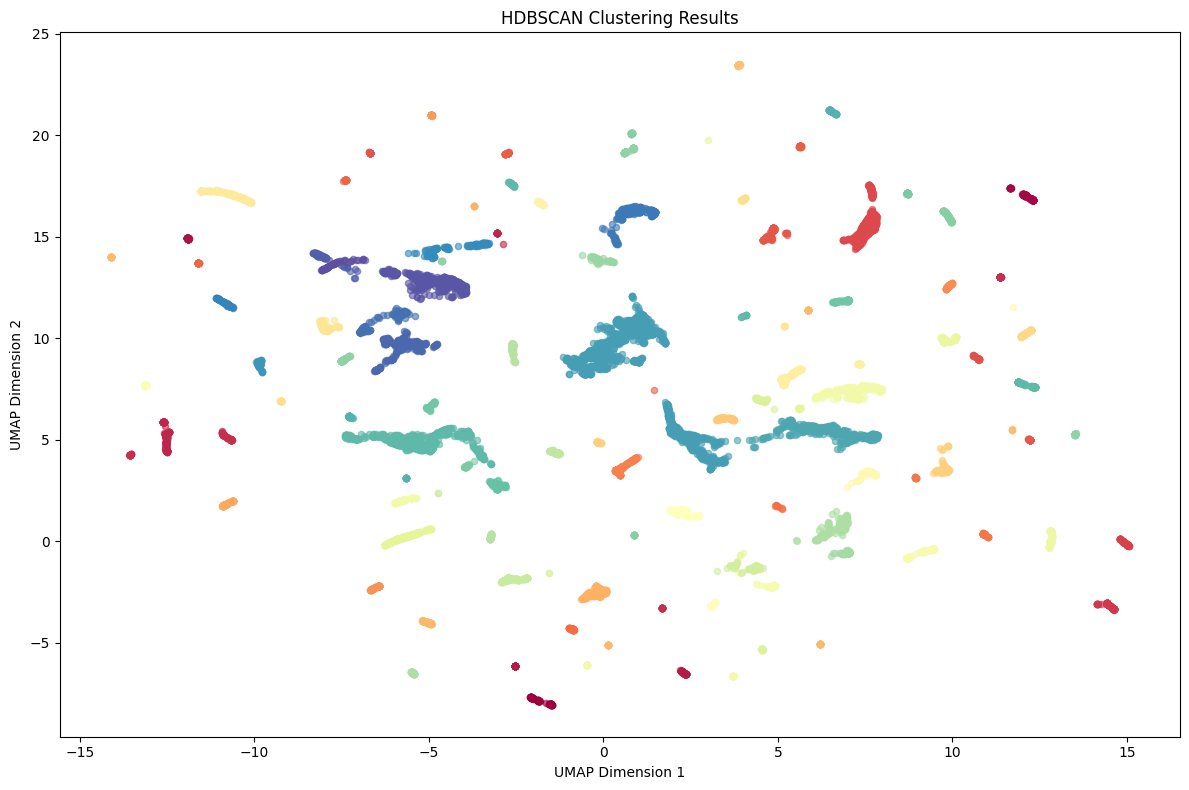

In [14]:
# Visualize clusters using 2D UMAP
print("Creating 2D visualization...")
from umap import UMAP
umap_2d = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.0, verbose=True, n_jobs=-1)
embeddings_2d = umap_2d.fit_transform(embeddings_reduced)

plt.figure(figsize=(12, 8))
# Only show non-noise clusters
unique_labels = [k for k in set(cluster_labels) if k != -1]
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    marker = 'o'
    alpha = 0.6
    
    class_member_mask = (cluster_labels == k)
    xy = embeddings_2d[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, alpha=alpha, s=20)

plt.title('HDBSCAN Clustering Results')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.tight_layout()
plt.show()


In [15]:
# Display sample comments from each cluster
print("\n" + "="*80)
print("Sample comments from each cluster:")
print("="*80)

for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        print(f"\n【Noise Points】({cluster_sizes[cluster_id]} points)")
    else:
        print(f"\n【Cluster {cluster_id}】({cluster_sizes[cluster_id]} points)")
    
    cluster_comments = filter_df[filter_df['cluster_label'] == cluster_id]['content_desc'].tolist()
    sample_size = min(5, len(cluster_comments))
    samples = np.random.choice(cluster_comments, size=sample_size, replace=False)
    
    for i, comment in enumerate(samples, 1):
        print(f"  {i}. {comment[:100]}..." if len(comment) > 100 else f"  {i}. {comment}")



Sample comments from each cluster:

【Noise Points】(15965 points)
  1. 藿香正气水
好灵啊
不舒服就喝它
没错 ​​​
  2. 带酒精的藿香正气水味道绝了 没干吐 不能涂便宜 ​​​
  3. 搭班的三个保安举着藿香正气口服液隔空干杯 05后的世界还是我不懂了[嘻嘻] ​
  4.  多云转阴13~9℃。今早带娃去医院看医生还算很顺利，没等多长时间就看到医生，面诊无大碍抽血化验各项指标正常，开一盒医院内部研制的藿香正气颗粒完事，医嘱待这次痊愈可以来找她调理娃的脾胃，脸上的小白片就...
  5. 藿香正气片快吃上[苦涩] 可怜的兔几~ 抱抱~ 担心你~ ​

【Cluster 0】(98 points)
  1. 交警便民点真牛逼，发藿香正气水，这不喝了就酒驾了？ ​​​
  2. “夏季交通安全整治行动”酒驾警示大直播

 咖啡含酒精、蛋黄派、荔枝、漱口水，藿香正气水，服用了这些都能测出酒精含量？服用后开车算不算酒驾？来听听渭南公安交警怎么说！ ​​​
  3.   2023年第15期【藿香正气水醉驾案】
【案情回顾】2020年8月7日23时许，被告人陈某酒后驾驶小型轿车从灌南县新安镇润天都汇小区出发行驶至灌南县妇幼保健所门前路段，追尾撞击前方同向行驶由姚某驾...
  4. 【[话筒]5月23日 FM91.8云南交通之声《全省交通纵贯线》】  [汗]“我知道喝酒不能开车，我喝的是藿香正气水” 近日，玉溪峨山一酒司机被交警查获时辩解说：没喝酒，只是喝了藿香正气水。如果真喝了...
  5. 【男子“酒驾”上高速被查，谎称是因为喝了藿香正气水】2023年4月7日晚，四川省公安厅高速公路公安局六分局一大队民警依托荥经安检站开展“春季守护行动”专项整治，23时30分许，民警对一辆川L***8号...

【Cluster 1】(184 points)
  1. 炒花生芽 桂花小米糕 白果芦笋百合 藿香正气和阿姐给的冰块[允悲]  ​
  2. 隔壁海王星辰推出了藿香正气水味的雪糕
嗯！还免费派送
yue～～ ​​​
  3. 炎热的夏天，来一根藿香正气雪糕真是爽
  4. 哈哈哈哈 我需要这个 给雪糕热一热是不是就变成藿香正气水了
  5. 藿香正气水➕陈皮味的雪糕
很努力的吃了三口 ​​​

【Cl

In [16]:
# Filter out noise and keep only meaningful clusters
meaningful_df = filter_df[filter_df['is_noise'] == False].copy()

print(f"\nOriginal comments: {len(filter_df)}")
print(f"Meaningful comments (after removing noise): {len(meaningful_df)}")
print(f"Noise removed: {len(filter_df) - len(meaningful_df)} ({((len(filter_df) - len(meaningful_df))/len(filter_df)*100):.2f}%)")

# Summary by cluster
print("\nMeaningful clusters summary:")
cluster_summary = meaningful_df.groupby('cluster_label').agg({
    'content_desc': 'count',
    'data_channel': lambda x: x.value_counts().to_dict()
}).rename(columns={'content_desc': 'count'})

for cluster_id, row in cluster_summary.iterrows():
    print(f"\nCluster {cluster_id}: {row['count']} comments")
    print(f"  Channels: {row['data_channel']}")



Original comments: 27838
Meaningful comments (after removing noise): 11873
Noise removed: 15965 (57.35%)

Meaningful clusters summary:

Cluster 0: 98 comments
  Channels: {'微博': 92, '小红书': 6}

Cluster 1: 184 comments
  Channels: {'微博': 163, '小红书': 21}

Cluster 2: 61 comments
  Channels: {'微博': 52, '小红书': 9}

Cluster 3: 124 comments
  Channels: {'微博': 122, '小红书': 2}

Cluster 4: 217 comments
  Channels: {'微博': 201, '小红书': 16}

Cluster 5: 162 comments
  Channels: {'微博': 151, '小红书': 11}

Cluster 6: 115 comments
  Channels: {'小红书': 58, '微博': 57}

Cluster 7: 91 comments
  Channels: {'微博': 60, '小红书': 31}

Cluster 8: 536 comments
  Channels: {'微博': 359, '小红书': 177}

Cluster 9: 72 comments
  Channels: {'小红书': 43, '微博': 29}

Cluster 10: 205 comments
  Channels: {'微博': 115, '小红书': 90}

Cluster 11: 99 comments
  Channels: {'微博': 89, '小红书': 10}

Cluster 12: 68 comments
  Channels: {'微博': 63, '小红书': 5}

Cluster 13: 70 comments
  Channels: {'微博': 67, '小红书': 3}

Cluster 14: 61 comments
  Channels: {'

In [17]:
meaningful_df[['content_desc', 'pred_province', 'create_time','data_channel','cluster_label']] \
    .sort_values(by='create_time', ascending=True) \
    .reset_index(drop=True)

,content_desc,pred_province,create_time,data_channel,cluster_label
0,前几天不舒服去看了医生，说我中暑了拿点藿香正气胶囊吃就好了，自从吃了它我就更难受了，吃过它坚...,NaN,2020-05-22 22:31:03,小红书,56
1,作为一个重度咖啡爱好者，每次看到新品都想尝试，虽然每次尝试几乎都踩雷。这次也不例外，附近便利...,NaN,2020-11-25 13:02:08,小红书,39
2,前两天突然就肠胃炎，先是发烧，然后疯狂拉肚子，还想吐，又不想去医院打吊瓶，一开始吃了肠炎宁颗...,NaN,2020-12-04 09:49:26,小红书,56
3,希爵夫Xerjoff - XXY\n这瓶香水100ml/600euro约等于约等于💰4800...,NaN,2020-12-21 19:31:34,小红书,36
4,太极藿香正气口服液,NaN,2021-06-01 14:20:38,小红书,21
...,...,...,...,...,...
11868,下班到家弟弟高烧39.9，爸爸用西医吃退烧药\n我用藿香正气水棉花塞肚脐+推胳膊+湿毛巾敷额...,上海,2023-12-20 19:57:43,微博,53
11869,我女儿发烧39℃\n推天河水10分钟\n还用藿香正气水做的脐疗\n退烧，睡了 ​​​,黑龙江,2023-12-20 21:15:04,微博,53
11870,胃痛（其实也不知道到底是不是胃）晚上忍痛坚持两小时忙完孩子和家务 想起藿香正气 赶紧吃了四粒...,江苏,2023-12-20 22:25:58,微博,56
11871,藿香正气水 喝一口 yue一天 ​​​,内蒙古,2023-12-20 22:39:12,微博,14


In [18]:
# save the meaningful_df
meaningful_df.to_csv('/home/mzyy1001/business/data/2_meaningful_df.csv', index=False)

In [19]:
meaningful_df = pd.read_csv('/home/mzyy1001/business/data/2_meaningful_df.csv')

### 使用LLM根据问题对每个问题打标，判断该cluster对问卷问题是否有意义

#### SSR实现

Step A：对所有 cluster 做 topic summary + relevance（只做一次，不依赖问卷问题）
Step B：对每个问卷问题生成 anchors
Step C：对所有 cluster 的 topic 与该问卷题目做 SSR → 得到 topic-level 方向（权重）
Step D：对 cluster 内所有评论做 SSR → 得到 raw cluster pmf
Step E：根据 relevance / 你自己设置的规则决定保留哪些 cluster
Step F：根据权重做 weighted aggregation → 得到 predicted pmf

In [20]:
import numpy as np

# ----------------------------
# 1. Cosine similarity
# ----------------------------
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

# ----------------------------
# 2. SSR 核心函数
# ----------------------------
def ssr_score(text: str, encoder, anchor_embeddings):
    """
    text: 待量化评论
    encoder: 一个函数，输入文本 -> 输出 embedding
    anchor_embeddings: 长度为 len(anchor_embeddings) 的 list，每个是一个 anchor 的 embedding
    
    返回:
        pmf: 概率分布 (长度为 len(anchor_embeddings))
        mean_score: 加权平均得分 (1~len(anchor_embeddings))
    """

    # 编码文本
    v = encoder.encode(text)

    # 与anchors 计算 cosine
    sims = np.array([cosine_sim(v, a) for a in anchor_embeddings], dtype=float)

    # min-subtraction
    sims = sims - sims.min()

    # 避免全 0
    if sims.sum() == 0:
        sims += 1e-8

    # 归一化得到 pmf
    pmf = sims / sims.sum()

    # mean (1~5)
    mean_score = np.dot(np.arange(1, len(anchor_embeddings)+1), pmf)

    return pmf, mean_score

In [32]:
relevance_prompt_template = '''
你是一名用户调研分析专家。

我会给你一组来自同一个语义簇（cluster）的主题，以及一个问卷题目。
请你判断该 cluster 的主题是否与该问卷题目所测量的内容相关。

请严格按以下 JSON 格式输出（注意字段和值都必须一致）：

{{
  "is_relevant": "相关 或 不相关"
}}

判断原则（非常重要）：
- 只要评论内容能表达对问卷题目所测维度的看法、情绪、态度或体验，即视为“相关”。
- 如果评论是闲聊、吐槽客服、物流、活动、广告、无意义文本、表情或与产品评价无关，则视为“不相关”。
- 判断基于该 cluster 的整体趋势，而不是个别评论。

下面是问卷题目：
{QUESTION}

下面是问卷题目可供选择的答案：
{OPTIONS}

下面是该 cluster 的主题：
{CLUSTER_TOPIC}

请严格按以下 JSON 格式输出：
{{
  "is_relevant": "相关 或 不相关"
}}
'''

topic_only_prompt = '''
你是一名用户调研分析专家。

我会给你一组来自同一个语义簇（cluster）的用户评论。
请你用一句话描述该 cluster 的主题（基于整体内容，而不是个别评论）。

请严格按以下 JSON 格式输出（注意字段和值都必须一致）：

{{
  "cluster_topic": "<一句话主题描述>"
}}

下面是该 cluster 的评论（每条之间用换行分隔）：
{CLUSTER_COMMENTS}

请严格按以下 JSON 格式输出：
{{
  "cluster_topic": "<一句话主题描述>"
}}
'''

anchor_prompt = '''
你是一名专业的问卷语义建模专家。

我会给你一个问卷题目和该题目的所有选项。
你的任务是为每个选项生成一个 "语义锚点句子（anchor sentence）"。

要求：
1. 每个锚点句子必须是自然语言表达，而不是重复选项文本本身。
2. 每个锚点必须清晰表达该选项所代表的态度或立场。
3. 锚点句子要尽可能具体、生动、带情绪或明确倾向（方便进行语义相似度计算）。
4. 输出顺序必须与选项顺序完全一致。
5. 锚点句子越像真实用户说的话越好。

请严格按以下 JSON 格式输出：
{{
  "anchors": [
    "<对应选项1 的 anchor sentence>",
    "<对应选项2 的 anchor sentence>",
    ...
  ]
}}

下面是问卷题目：
{QUESTION}

下面是该题目的选项（按顺序）：
{OPTIONS}
'''

In [43]:
import openai
import json

base_url = "http://127.0.0.1:8071/v1"
api_key = "EMPTY"
model_id = "/home/mzyy1001/data/whp/models/qwen3/Qwen3-8B"

client = openai.OpenAI(base_url=base_url, api_key=api_key)

In [44]:
from openai import OpenAI

client = OpenAI(
    base_url="http://127.0.0.1:8071/v1",
    api_key="EMPTY",
    timeout=600,
)

resp = client.chat.completions.create(
    model="/home/mzyy1001/data/whp/models/qwen3/Qwen3-8B",
    messages=[{"role": "user", "content": "只输出：OK"}],
    temperature=0,
    max_tokens=16,
)

print(resp.choices[0].message.content)

OK


In [46]:
# ---------------------------------------------------
# Step A：cluster topic（只做一次，不含 relevance）
# ---------------------------------------------------
cluster_topics = {}
for cluster_id in meaningful_df["cluster_label"].unique():

    # 从 cluster 抽样评论
    comments = meaningful_df[meaningful_df["cluster_label"] == cluster_id]["content_desc"].tolist()[:20]

    prompt = topic_only_prompt.format(
        CLUSTER_COMMENTS="\n".join(comments)
    )

    resp = client.chat.completions.create(
        model=model_id,
        messages=[{"role": "user", "content": prompt}],
    )

    raw = resp.choices[0].message.content.strip()
    print(raw)
    topic_json = json.loads(raw)

    cluster_topics[int(cluster_id)] = topic_json["cluster_topic"]

print("Cluster topics computed.\n")

# save the cluster_topics, 中文防止乱码
with open('/home/mzyy1001/business/data/3_cluster_topics.json', 'w') as f:
    json.dump(cluster_topics, f, ensure_ascii=False)

{
  "cluster_topic": "用户分享了因肠胃不适（如腹泻、呕吐、腹痛等）而使用藿香正气类产品缓解症状的经历。"
}
{
  "cluster_topic": "用户对过期藿香正气水的使用、担忧及体验分享"
}
{
  "cluster_topic": "用户普遍将藿香正气水视为夏季必备的防暑降温饮品或药物，同时带有轻松幽默的使用场景描述。"
}
{
  "cluster_topic": "用户对含有藿香正气水味道的产品（如面膜、护肤品、内调饮品等）的使用体验和感受进行描述，主要涉及气味、效果及使用场景。"
}
{
  "cluster_topic": "用户对藿香正气水苦涩口感的普遍不满与对其药用价值的认可"
}
{
  "cluster_topic": "用户评论围绕一款具有藿香正气水味的香水展开，涉及其味道、使用体验及与其他香水的对比。"
}
{
  "cluster_topic": "用户对药品价格持续上涨以及医保政策变化的不满和关注"
}
{
  "cluster_topic": "家长使用藿香正气水及相关方法缓解婴幼儿感冒症状的实践与经验分享"
}
{
  "cluster_topic": "藿香正气水主要用于祛湿和缓解暑湿引起的不适，而非治疗中暑，且存在特定使用禁忌。"
}
{
  "cluster_topic": "用户分享了关于甲流的预防、治疗和用药经验，尤其强调了藿香正气水在缓解症状和退烧中的作用。"
}
{
  "cluster_topic": "用户分享使用藿香正气水及其衍生方法驱蚊、防中暑和调理身体的体验与效果"
}
{
  "cluster_topic": "用户分享使用藿香正气水及相关方法缓解感冒发烧、肠胃不适等症状的经验与心得。"
}
{
  "cluster_topic": "用户对藿香正气水味道的强烈负面评价以及对其药效的讨论"
}
{
  "cluster_topic": "用户分享使用藿香正气水治疗湿疹、汗疱疹、荨麻疹等皮肤问题的经验和效果"
}
{
  "cluster_topic": "藿香正气水与头孢类药物不能同时服用，以免引发双硫仑样反应，导致严重健康风险。"
}
{
  "cluster_topic": "用户分享与母亲之间围绕藿香正气水的日常互动和情感联结"
}
{
  "cluster_topic"

In [47]:
cluster_topics = json.load(open('/home/mzyy1001/business/data/3_cluster_topics.json'))

In [51]:
# ---------------------------------------------------
# Step B~E：每道题都重新判断 relevance + SSR
# ---------------------------------------------------
from collections import defaultdict
survey_results = defaultdict(lambda: defaultdict(dict))
EPS = 0.1

sub_surveys = [8, 9, 11]

interested_questions_ids = {
    (8,3),
    (8,4),
    (9,3),
    (9,4),
    (9,5),
    (11,3)
}

for survey_id, sub_survey in results.items():
    for sub_survey_id, questions in sub_survey.items():

        if sub_survey_id not in sub_surveys:
            continue

        for unique_id, data in tqdm(questions.items()):

            if (int(sub_survey_id), int(unique_id.split('_')[-1])) not in interested_questions_ids:
                continue

            q_type = data['type']
            if q_type not in ['single', 'mul']:
                continue

            question_text = data['question']
            if '年龄' in question_text or '常驻' in question_text:
                continue

            true_counts = data['answers']
            option_list = list(true_counts.keys())
            options_str = ", ".join(option_list)

            # ---------------------------------------------------
            # Step B：为该问卷题生成 anchors
            # ---------------------------------------------------
            anchor_resp = client.chat.completions.create(
                model=model_id,
                messages=[{
                    "role": "user",
                    "content": anchor_prompt.format(
                        QUESTION=question_text,
                        OPTIONS=options_str
                    )
                }],
                extra_body={"chat_template_kwargs": {"enable_thinking": True}}
            )

            anchor_json = json.loads(anchor_resp.choices[0].message.content.strip())            
            anchors = anchor_json["anchors"]
            anchor_embeddings = [model.encode(a) for a in anchors]


            # ============================================
            # Step C：第一层 cluster for-loop（依赖问题）
            #         用该问题重新判断 cluster relevance
            # ============================================

            cluster_relevance = {}   # per-question relevance
            cluster_topic_embs = []  # 用于 SSR 的 topic embedding

            for cluster_id in cluster_topics.keys():

                topic_text = cluster_topics[cluster_id]

                relevance_prompt = relevance_prompt_template.format(
                    QUESTION=question_text,
                    OPTIONS=options_str,
                    CLUSTER_TOPIC=topic_text
                )

                relevance_resp = client.chat.completions.create(
                    model=model_id,
                    messages=[{"role": "user", "content": relevance_prompt}],
                    extra_body={"chat_template_kwargs": {"enable_thinking": True}}
                )

                json_part = relevance_resp.choices[0].message.content.strip()
                rel_json = json.loads(json_part)

                cluster_relevance[cluster_id] = rel_json["is_relevant"]

                # 收集 topic embeddings（不分相关性）
                cluster_topic_embs.append(model.encode(topic_text))


            # ============================================
            # Step D：第二层 cluster for-loop（SSR）
            #         soft relevance + topic SSR + 评论 SSR
            # ============================================

            # 先计算：问卷题 vs cluster topics 的 SSR（topic-level）
            topic_pmf_all, _ = ssr_score(
                question_text,
                model,
                cluster_topic_embs
            )

            cluster_weights = {}
            cluster_pmf_results = {}

            for idx, cluster_id in enumerate(cluster_topics.keys()):

                # soft relevance（依赖问题）
                if cluster_relevance[cluster_id] == "相关":
                    w_c = topic_pmf_all[idx]
                else:
                    w_c = topic_pmf_all[idx] * EPS

                cluster_weights[cluster_id] = float(w_c)

                # 评论级 SSR
                dfc = meaningful_df[meaningful_df["cluster_label"] == int(cluster_id)].copy()
                if len(dfc) == 0:
                    continue

                dfc["ssr_pmf"] = dfc["content_desc"].apply(
                    lambda x: ssr_score(x, model, anchor_embeddings)[0]
                )

                raw_pmf = np.mean(np.stack(dfc["ssr_pmf"].values), axis=0)

                cluster_pmf_results[cluster_id] = w_c * raw_pmf


            # ---------------------------------------------------
            # Step E：加权汇总 cluster → final pmf
            # ---------------------------------------------------
            total_w = sum(cluster_weights.values()) + 1e-8
            
            # 确保 final_pmf 是数组
            if len(cluster_pmf_results) > 0:
                # 使用 np.sum 确保结果是数组
                final_pmf = np.sum(list(cluster_pmf_results.values()), axis=0) / total_w
            else:
                # 如果没有相关 cluster，返回均匀分布
                final_pmf = np.ones(len(option_list)) / len(option_list)
            
            # 确保 final_pmf 是 numpy 数组
            final_pmf = np.array(final_pmf)
            
            # 归一化权重（使总和为1）
            total_w_normalized = sum(cluster_weights.values()) + 1e-8
            normalized_cluster_weights = {k: float(v / total_w_normalized) for k, v in cluster_weights.items()}

            survey_results[survey_id][sub_survey_id][unique_id] = {
                "question": question_text,
                "options": option_list,
                "true_distribution": true_counts,
                "predicted_pmf": final_pmf.tolist(),
                "cluster_weights": normalized_cluster_weights,
                "cluster_relevance": cluster_relevance
            }

            print("Predicted:", final_pmf)

            break

        break

    break


 29%|██▊       | 2/7 [10:03<25:08, 301.75s/it]

Predicted: [0.11922915 0.25802322 0.11184844 0.36948573 0.14141341]


In [ ]:
# save the survey_results
# Convert defaultdict to regular dict for JSON serialization
def convert_to_dict(obj):
    """Recursively convert defaultdict to dict"""
    if isinstance(obj, defaultdict):
        return {k: convert_to_dict(v) for k, v in obj.items()}
    elif isinstance(obj, dict):
        return {k: convert_to_dict(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_dict(item) for item in obj]
    else:
        return obj

survey_results_dict = convert_to_dict(survey_results)

with open(f'/home/mzyy1001/business/survey_ssr_exp.ipynb/results/eps_{EPS}.json', 'w', encoding='utf-8') as f:
    json.dump(survey_results_dict, f, ensure_ascii=False, indent=2)

FileNotFoundError: [Errno 2] No such file or directory: '/home/houwanlong/survey_2025/exps/12.01-12.05/results/eps_0.1.json'